In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import random

## Load mnist data and pairs them

In [20]:
def load_mnist_pairs():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_data = np.concatenate([x_train, x_test])
    y_data = np.concatenate([y_train, y_test])
    x_data = x_data.astype("float32") / 255.
    x_data = np.expand_dims(x_data, axis=-1)

    digit_indices = [np.where(y_data == i)[0] for i in range(10)]

    # Create pairs
    pairs, labels = [], []
    for _ in range(30000):
        # Positive pair
        digit = random.randint(0, 9)
        idx1, idx2 = np.random.choice(digit_indices[digit], 2, replace=False)
        pairs.append([x_data[idx1], x_data[idx2]])
        labels.append(1)

        # Negative pair
        d1, d2 = random.sample(range(10), 2)
        idx1 = np.random.choice(digit_indices[d1])
        idx2 = np.random.choice(digit_indices[d2])
        pairs.append([x_data[idx1], x_data[idx2]])
        labels.append(0)

    return np.array(pairs), np.array(labels).astype("float32")

## Model Definations

In [21]:
def create_base_model(input_shape):
    input = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu')(input)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))(x)
    return models.Model(input, x)

## Binary Cross Entropy Loss

In [22]:
def build_bce_model(input_shape):
    base_network = create_base_model(input_shape)
    input_a = layers.Input(shape=input_shape)
    input_b = layers.Input(shape=input_shape)

    emb_a = base_network(input_a)
    emb_b = base_network(input_b)

    x = layers.concatenate([emb_a, emb_b])
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model([input_a, input_b], x)
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

## Contrastive Loss

In [23]:
def contrastive_loss(y_true, y_pred):
    margin = 1.0
    return tf.reduce_mean(y_true * tf.square(y_pred) + (1 - y_true) * tf.square(tf.maximum(margin - y_pred, 0)))

def build_contrastive_model(input_shape):
    base_network = create_base_model(input_shape)
    input_a = layers.Input(shape=input_shape)
    input_b = layers.Input(shape=input_shape)

    emb_a = base_network(input_a)
    emb_b = base_network(input_b)

    l2_distance = layers.Lambda(lambda tensors: tf.sqrt(tf.reduce_sum(tf.square(tensors[0] - tensors[1]), axis=1, keepdims=True)))(
        [emb_a, emb_b])

    model = models.Model([input_a, input_b], l2_distance)
    model.compile(loss=contrastive_loss, optimizer='adam')
    return model

## Triplet Loss

In [24]:
def triplet_loss(y_true, y_pred):
    anchor, positive, negative = y_pred[:, 0], y_pred[:, 1], y_pred[:, 2]
    positive_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
    negative_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)
    margin = 1.0
    loss = tf.maximum(0.0, positive_dist - negative_dist + margin)
    return tf.reduce_mean(loss)

def build_triplet_model(input_shape):
    base_network = create_base_model(input_shape)
    input_anchor = layers.Input(shape=input_shape, name='anchor')
    input_positive = layers.Input(shape=input_shape, name='positive')
    input_negative = layers.Input(shape=input_shape, name='negative')

    embedding_anchor = base_network(input_anchor)
    embedding_positive = base_network(input_positive)
    embedding_negative = base_network(input_negative)

    # Concatenate the embeddings for custom loss calculation
    # The loss function will receive a tensor of shape (batch_size, 3, embedding_dim)
    merged_vector = layers.concatenate([embedding_anchor, embedding_positive, embedding_negative], axis=1)
    merged_vector = layers.Reshape((3, 128))(merged_vector) # Reshape to (batch_size, 3, 128)

    model = models.Model(inputs=[input_anchor, input_positive, input_negative], outputs=merged_vector)
    model.compile(loss=triplet_loss, optimizer='adam')
    return model

## Train the Model with BCE and Constructive loss

In [25]:
pairs, labels = load_mnist_pairs()
input_shape = pairs[0][0].shape

# Split data
x_train, x_test, y_train, y_test = train_test_split(pairs, labels, test_size=0.2)

# BCE
print("Model trainign started with BCE loss")
bce_model = build_bce_model(input_shape)
history_bce = bce_model.fit([x_train[:,0], x_train[:,1]], y_train, validation_split=0.2, epochs=10)

# Contrastive
print("Model trainign started with contrastive loss")
contrast_model = build_contrastive_model(input_shape)
history_contrast = contrast_model.fit([x_train[:,0], x_train[:,1]], y_train, validation_split=0.2, epochs=10)

Model trainign started with BCE loss
Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5800 - loss: 0.6288 - val_accuracy: 0.9208 - val_loss: 0.1982
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9503 - loss: 0.1406 - val_accuracy: 0.9808 - val_loss: 0.0656
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9873 - loss: 0.0457 - val_accuracy: 0.9861 - val_loss: 0.0440
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9934 - loss: 0.0234 - val_accuracy: 0.9891 - val_loss: 0.0370
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9958 - loss: 0.0155 - val_accuracy: 0.9902 - val_loss: 0.0342
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9974 - loss: 0.0110 - val_accuracy: 0.9901 - val_loss: 0.0321
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9991 - loss: 0.0051 - val_accuracy: 0.9880 - val_loss: 0.0442
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/s

## Train The Model with Triplet Loss

In [26]:
def create_triplets(x_data, y_data, n_samples=30000):
    digit_indices = [np.where(y_data == i)[0] for i in range(10)]
    triplets = []
    for _ in range(n_samples):
        a_digit = random.randint(0, 9)
        a, p = np.random.choice(digit_indices[a_digit], 2, replace=False)
        n_digit = random.choice([i for i in range(10) if i != a_digit])
        n = np.random.choice(digit_indices[n_digit])
        triplets.append([x_data[a], x_data[p], x_data[n]])
    return np.array(triplets)

# Load data
(x_train_m, y_train_m), (_, _) = mnist.load_data()
x_train_m = x_train_m.astype("float32") / 255.
x_train_m = np.expand_dims(x_train_m, axis=-1)

# Generate triplets
triplets = create_triplets(x_train_m, y_train_m, n_samples=30000)

# Split manually into train/val (80/20)
split_idx = int(0.8 * len(triplets))
anchor_train = triplets[:split_idx, 0]
pos_train = triplets[:split_idx, 1]
neg_train = triplets[:split_idx, 2]

anchor_val = triplets[split_idx:, 0]
pos_val = triplets[split_idx:, 1]
neg_val = triplets[split_idx:, 2]

y_dummy_train = np.zeros(len(anchor_train))
y_dummy_val = np.zeros(len(anchor_val))

# Build and train the model
triplet_model = build_triplet_model((28, 28, 1))
history_triplet = triplet_model.fit(
    [anchor_train, pos_train, neg_train],
    y_dummy_train,
    validation_data=([anchor_val, pos_val, neg_val], y_dummy_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.2188 - val_loss: 0.0470
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0309 - val_loss: 0.0306
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0196 - val_loss: 0.0212
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0126 - val_loss: 0.0215
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0119 - val_loss: 0.0168
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0068 - val_loss: 0.0150
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0043 - val_loss: 0.0203
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0051 - val_loss: 0.0182
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0052 - val_loss: 0.0136
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0034 - val_loss: 0.0135


## Visualization

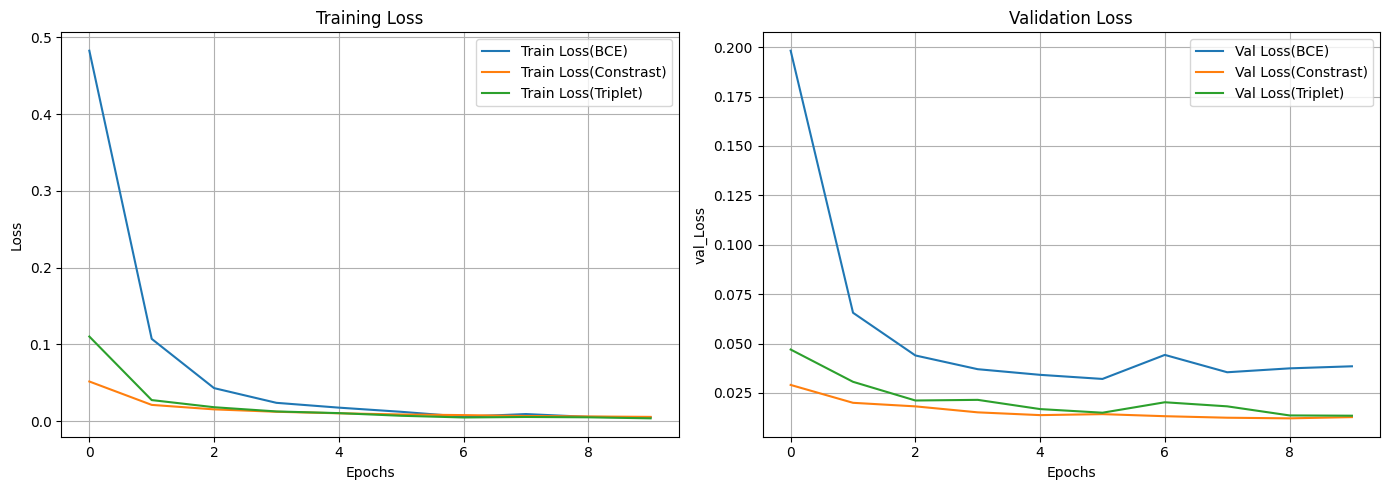

In [27]:
import matplotlib.pyplot as plt

def plot_all_losses(history_bce, history_contrast, history_triplet):
    plt.figure(figsize=(14,5))

    # ===== BCE Plot =====
    plt.subplot(1, 2, 1)
    plt.plot(history_bce.history['loss'], label='Train Loss(BCE)')
    plt.plot(history_contrast.history['loss'], label='Train Loss(Constrast)')
    plt.plot(history_triplet.history['loss'], label='Train Loss(Triplet)')
    plt.title("Training Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    # ===== Contrastive Plot =====
    plt.subplot(1, 2, 2)
    plt.plot(history_bce.history['val_loss'], label='Val Loss(BCE)')
    plt.plot(history_contrast.history['val_loss'], label='Val Loss(Constrast)')
    plt.plot(history_triplet.history['val_loss'], label='Val Loss(Triplet)')

    plt.title("Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("val_Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function to display the plots
plot_all_losses(history_bce, history_contrast, history_triplet)